# Phase identification: Bennett comparison plus the Venkatarathnam-Oellrich parameter

## Objective and classification

This **verification** study demonstrates and compares the `torch-flash`
implementations of all five phase-identification criteria selected by
Bennett and Schmidt together with the Venkatarathnam-Oellrich
phase-identification parameter. All six diagnostics are applied to Bennett
and Schmidt's five illustrative cases:

1. pure methane \(P\)-\(T\);
2. methane/carbon-dioxide \(P\)-composition at 180 K;
3. impure-CO₂ injection into North Ward Estes oil;
4. the five-component Gozalpour synthetic condensate; and
5. the ten-component ECLIPSE example reservoir fluid.

Success requires the calculated V/L/LV/LL/LLV regions to recover the
topology and method-to-method differences of Figures 2-6, not merely finite
homogeneous-state scores. Following the paper, every feed is therefore
split by a multiphase Gibbs-energy calculation before the selected
identification criterion is applied to every distinct equilibrium phase.
Phase identification remains a diagnostic: it labels the equilibrium phases
but does not enter their material balance or fugacity equations.

## Defining sources and conventions

- Bennett and Schmidt, *Energy & Fuels* 31 (2017), 3370-3379,
  [doi:10.1021/acs.energyfuels.6b02316](https://doi.org/10.1021/acs.energyfuels.6b02316).
- Michelsen and Mollerup, *Thermodynamic Models*, 2nd ed. (2007),
  chapter 12: the printed SRK caption and three-phase state imply different
  \(k_{12}\) conventions; both are tested below.
- Li and Firoozabadi, *SPE Journal* 17 (2012), 1096-1107,
  [doi:10.2118/129844-PA](https://doi.org/10.2118/129844-PA):
  North Ward Estes component data and an independent three-phase state used
  by Bennett and Schmidt.
- NIST Chemistry WebBook SRD 69: n-hexadecane critical properties.
- Pedersen, Christensen, and Shaikh, *Phase Behavior of Petroleum
  Reservoir Fluids*, 3rd ed. (2024), Eqs. 5.1-5.5: characterization of
  incomplete ECLIPSE pseudo-component rows.
- Venkatarathnam and Oellrich, *Fluid Phase Equilibria* 301 (2011), 225-233,
  [doi:10.1016/j.fluid.2010.12.001](https://doi.org/10.1016/j.fluid.2010.12.001):
  the dimensionless phase-identification parameter used here.

All public inputs are SI: kelvin, pascal, m³/mol, and kg/mol. Plots show bar
only after the explicit conversion \(1\ {\rm bar}=10^5\ {\rm Pa}\).
Calculations use `torch.float64`.

In [1]:
from __future__ import annotations

import gc
import os
import platform
from collections.abc import Callable
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython import get_ipython
from IPython.display import display
from matplotlib.colors import BoundaryNorm, ListedColormap

import torch_flash
from torch_flash import (
    ChemicalState,
    ComponentSet,
    GridEquilibrium,
    GridFlashOptions,
    SCNDistribution,
    component_set,
    flash_grid,
    identify_grid_phases,
    identify_phase,
    pedersen_cubic_properties,
    peng_robinson_1978,
    soave_redlich_kwong,
    solve_binary_three_phase_invariant,
)
from torch_flash.constants import R

torch.set_default_dtype(torch.float64)
PYTORCH_THREADS = int(os.environ.get("TORCH_FLASH_PHASE_ID_THREADS", "1"))
if PYTORCH_THREADS < 1:
    raise ValueError("TORCH_FLASH_PHASE_ID_THREADS must be positive")
torch.set_num_threads(PYTORCH_THREADS)
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
plt.style.use("seaborn-v0_8-whitegrid")

GRID_POINTS = int(os.environ.get("TORCH_FLASH_PHASE_ID_GRID_POINTS", "100"))
if GRID_POINTS < 3:
    raise ValueError("TORCH_FLASH_PHASE_ID_GRID_POINTS must be at least 3")
GRID_CHUNK_SIZE = int(os.environ.get("TORCH_FLASH_PHASE_ID_GRID_CHUNK_SIZE", "2048"))
if GRID_CHUNK_SIZE < 1:
    raise ValueError("TORCH_FLASH_PHASE_ID_GRID_CHUNK_SIZE must be positive")
PIP_AUTODIFF_CHUNK_SIZE = int(
    os.environ.get("TORCH_FLASH_PHASE_ID_PIP_CHUNK_SIZE", "2048")
)
if PIP_AUTODIFF_CHUNK_SIZE < 1:
    raise ValueError("TORCH_FLASH_PHASE_ID_PIP_CHUNK_SIZE must be positive")
FALLBACK_WORKERS = int(os.environ.get("TORCH_FLASH_PHASE_ID_FALLBACK_WORKERS", "1"))
if FALLBACK_WORKERS < 1:
    raise ValueError("TORCH_FLASH_PHASE_ID_FALLBACK_WORKERS must be positive")

reproducibility = pd.Series(
    {
        "torch-flash": torch_flash.__version__,
        "PyTorch": torch.__version__,
        "Python": platform.python_version(),
        "platform": platform.platform(),
        "dtype": str(torch.get_default_dtype()),
        "grid points per axis": GRID_POINTS,
        "grid flash chunk size": GRID_CHUNK_SIZE,
        "PIP autodiff chunk size": PIP_AUTODIFF_CHUNK_SIZE,
        "random Gibbs fallback starts": int(
            os.environ.get("TORCH_FLASH_PHASE_ID_RANDOM_FALLBACK_STARTS", "8")
        ),
        "scalar fallback workers": FALLBACK_WORKERS,
        "PyTorch intra-op threads": torch.get_num_threads(),
    },
    name="value",
)
display(reproducibility.to_frame())
print(
    "Set TORCH_FLASH_PHASE_ID_GRID_POINTS=9 for the fast smoke profile or 500 "
    "for the paper's nominal illustrative-grid resolution. The default is 100 x 100."
)

,value
torch-flash,0.1.2
PyTorch,2.12.1
Python,3.13.14
platform,macOS-26.5.2-arm64-arm-64bit-Mach-O
dtype,torch.float64
grid points per axis,100
grid flash chunk size,2048
PIP autodiff chunk size,2048
random Gibbs fallback starts,8
scalar fallback workers,1


Set TORCH_FLASH_PHASE_ID_GRID_POINTS=9 for the fast smoke profile or 500 for the paper's nominal illustrative-grid resolution. The default is 100 x 100.


## The six criteria

Bennett and Schmidt select the following rules:

\[
T_c^{\rm Li}
=r_1\frac{\sum_j x_jV_{c,j}T_{c,j}}{\sum_jx_jV_{c,j}},
\qquad T>T_c^{\rm Li}\ \Rightarrow\ {\rm vapor},
\]

\[
\frac{V}{b}>r_2\ \Rightarrow\ {\rm vapor},
\qquad r_1=1,\quad r_2=1.75,
\]

\[
G(0.5)=\sum_j
\frac{x_j(K_j^{\rm Wilson}-1)}
{1+0.5(K_j^{\rm Wilson}-1)}>0
\ \Rightarrow\ {\rm vapor},
\]

\[
\left(\frac{\partial\kappa}{\partial T}\right)_P>0
\ \Rightarrow\ {\rm liquid},
\qquad
\left(\frac{\partial\alpha}{\partial T}\right)_P>0
\ \Rightarrow\ {\rm liquid}.
\]

Here
\[
\kappa=-\frac{1}{V}\left(\frac{\partial V}{\partial P}\right)_T,
\qquad
\alpha=\frac{1}{V}\left(\frac{\partial V}{\partial T}\right)_P.
\]

Venkatarathnam and Oellrich define

\[
\Pi =
V\left[
\frac{P_{VT}}{P_T}
-\frac{P_{VV}}{P_V}
\right],
\qquad
\Pi>1\ \Rightarrow\ {\rm liquid},\quad
\Pi\leq1\ \Rightarrow\ {\rm vapor},
\]

where \(P_T=(\partial P/\partial T)_V\),
\(P_V=(\partial P/\partial V)_T\), and the remaining symbols are second
derivatives at fixed composition. `torch-flash` evaluates all three
pressure-derivative rules with PyTorch autodiff, preserving the graph to
temperature and trainable EoS parameters. For \(\Pi\), nested
`torch.func.jvp` calls evaluate independent batched pressure derivatives
without constructing a dense cross-state Jacobian. The paper's optional
high-temperature inversion correction is not needed for the saturated phases
produced by a converged flash, which is the use studied here. For plotting,
every score is transformed to the same sign convention: **positive is
vapor-like, negative is liquid-like**.

In [2]:
METHODS = {
    "Li pseudo-critical T": "li-pseudo-critical-temperature",
    "Pedersen V/b": "pedersen-volume-to-covolume",
    "Perschke negative flash": "perschke-negative-flash",
    "d(kappa)/dT at P": "pasad-isothermal-compressibility-derivative",
    "d(alpha)/dT at P": "bennett-thermal-expansion-derivative",
    "Venkatarathnam-Oellrich PIP": (
        "venkatarathnam-oellrich-phase-identification-parameter"
    ),
}


@dataclass(frozen=True)
class PaperCase:
    """One two-dimensional state family from the comparison paper."""

    name: str
    model: object
    horizontal: torch.Tensor
    vertical_bar: torch.Tensor
    state_from_coordinates: Callable[[torch.Tensor, torch.Tensor], ChemicalState]
    horizontal_label: str
    assumption: str

    def grid_state(self) -> ChemicalState:
        """Build the batched TP state shown on this paper figure."""
        pressure_bar, horizontal = torch.meshgrid(
            self.vertical_bar,
            self.horizontal,
            indexing="ij",
        )
        return self.state_from_coordinates(horizontal, pressure_bar)


def pr_consistent_critical_volume(
    critical_temperature: torch.Tensor,
    critical_pressure: torch.Tensor,
) -> torch.Tensor:
    """Return Eq.-of-state-consistent PR critical volumes with Zc=0.3074."""
    return 0.3074 * R * critical_temperature / critical_pressure


def join_component_sets(
    names: tuple[str, ...],
    first: ComponentSet,
    *,
    critical_temperature: torch.Tensor,
    critical_pressure: torch.Tensor,
    acentric_factor: torch.Tensor,
    molar_mass: torch.Tensor,
    critical_volume: torch.Tensor,
) -> ComponentSet:
    """Append explicit pseudo-components to an existing component set."""
    if first.critical_volume is None:
        raise ValueError("base component set requires critical volumes")
    return ComponentSet(
        names,
        torch.cat((first.critical_temperature, critical_temperature)),
        torch.cat((first.critical_pressure, critical_pressure)),
        torch.cat((first.acentric_factor, acentric_factor)),
        torch.cat((first.molar_mass, molar_mass)),
        torch.cat((first.critical_volume, critical_volume)),
    )


def pressure_grid(low: float, high: float) -> torch.Tensor:
    """Return a paper-axis pressure grid in bar."""
    return torch.linspace(low, high, GRID_POINTS)


def linear_grid(low: float, high: float) -> torch.Tensor:
    return torch.linspace(low, high, GRID_POINTS)


def landmark_pressure_grid(
    low: float, high: float, landmark_pressure_bar: float
) -> torch.Tensor:
    """Return a monotone grid that samples a paper-reported invariant pressure."""
    grid = pressure_grid(low, high)
    closest = torch.argmin(torch.abs(grid - landmark_pressure_bar))
    grid[closest] = landmark_pressure_bar
    return torch.sort(grid).values

## Case definitions and parameter audit

The methane and CH₄/CO₂ cases are direct model reconstructions. The North
Ward Estes values are those tabulated by Li and Firoozabadi; because that
table omits \(V_c\), Li's weighting uses the PR-consistent
\(V_c=Z_cRT_c/P_c\), \(Z_c=0.3074\). The Gozalpour case uses the composition
and nonzero BICs printed by Bennett and Schmidt; n-C16 uses NIST critical
properties and \(\omega=0.749\). The ECLIPSE table does not publish
\(T_c,P_c,\omega,V_c\) for its seven lumped fractions, so those are estimated
with the repository's cited Pedersen PR characterization. This last case is
a transparent reconstruction, not an exact ECLIPSE property-table match.

In [3]:
# Case 1: pure methane, PR78.
methane_components = component_set(("methane",), dtype=torch.float64)
methane_model = peng_robinson_1978(methane_components)
methane_composition = torch.ones(1)


def methane_state(
    temperature: torch.Tensor, pressure_bar: torch.Tensor
) -> ChemicalState:
    return ChemicalState(temperature, pressure_bar * 1.0e5, methane_composition)


methane_case = PaperCase(
    "Figure 2 - pure methane P-T",
    methane_model,
    linear_grid(100.0, 1000.0),
    pressure_grid(0.5, 250.0),
    methane_state,
    "temperature / K",
    "Direct PR78 pure-component reconstruction.",
)

In [4]:
# Case 2: methane/carbon dioxide at 180 K, SRK.
#
# Michelsen and Mollerup's Figure 8 caption prints kij=0.08, but their
# independently printed three-phase state at 2.73 MPa
# (x1=0.199, x1II=0.781, y1=0.958) satisfies the standard SRK fugacity
# equations with kij=0.12. The latter is the numerical discriminator used
# here; the residual comparison is reported below.
binary_components = ComponentSet(
    ("methane", "carbon_dioxide"),
    torch.tensor([190.6, 304.2]),
    101325.0 * torch.tensor([45.4, 72.9]),
    torch.tensor([0.008, 0.228]),
    torch.tensor([0.01604, 0.04401]),
    torch.tensor([9.93e-5, 9.40e-5]),
)
binary_kij = torch.tensor([[0.0, 0.12], [0.12, 0.0]])
binary_model = soave_redlich_kwong(binary_components, kij=binary_kij)
BINARY_INVARIANT_NEWTON_TOLERANCE = 1.0e-11
binary_invariant = solve_binary_three_phase_invariant(
    binary_model,
    torch.tensor(180.0),
    torch.tensor(2.73e6),
    torch.tensor(
        [
            [0.199, 0.801],
            [0.781, 0.219],
            [0.958, 0.042],
        ]
    ),
    tolerance=BINARY_INVARIANT_NEWTON_TOLERANCE,
)
binary_invariant_pressure_bar = binary_invariant.pressure / 1.0e5
binary_invariant_methane_fractions = binary_invariant.phase_compositions[:, 0]
binary_invariant_residual = binary_invariant.residual_norm
binary_invariant_iterations = binary_invariant.iterations


def binary_state(
    methane_fraction: torch.Tensor, pressure_bar: torch.Tensor
) -> ChemicalState:
    composition = torch.stack((methane_fraction, 1.0 - methane_fraction), dim=-1)
    return ChemicalState(
        torch.full_like(pressure_bar, 180.0),
        pressure_bar * 1.0e5,
        composition,
    )


binary_case = PaperCase(
    "Figure 3 - CH4/CO2 P-x at 180 K",
    binary_model,
    linear_grid(0.001, 0.999),
    landmark_pressure_grid(0.5, 70.0, float(binary_invariant_pressure_bar)),
    binary_state,
    "feed methane mole fraction",
    "Michelsen-Mollerup SRK constants; kij=0.12 selected by their printed "
    "three-phase fugacity-equality state.",
)

In [5]:
# Case 3: 95 mol% CO2 + 5 mol% methane injection into North Ward Estes oil.
nwe_names = (
    "carbon_dioxide",
    "methane",
    "pc1",
    "pc2",
    "pc3",
    "pc4",
    "pc5",
)
nwe_tc = torch.tensor([304.2, 190.6, 343.64, 466.41, 603.07, 733.79, 923.2])
nwe_pc = 1.0e5 * torch.tensor([73.77, 46.0, 45.05, 33.51, 24.24, 18.03, 17.26])
nwe_omega = torch.tensor([0.225, 0.008, 0.13, 0.244, 0.6, 0.903, 1.229])
nwe_molar_mass = 1.0e-3 * torch.tensor(
    [44.01, 16.04, 38.4, 72.82, 135.82, 257.75, 479.95]
)
nwe_components = ComponentSet(
    nwe_names,
    nwe_tc,
    nwe_pc,
    nwe_omega,
    nwe_molar_mass,
    pr_consistent_critical_volume(nwe_tc, nwe_pc),
)
nwe_kij = torch.zeros((7, 7))
nwe_kij[0, 1:] = torch.tensor([0.12, 0.12, 0.12, 0.09, 0.09, 0.09])
nwe_kij[:, 0] = nwe_kij[0]
nwe_model = peng_robinson_1978(nwe_components, kij=nwe_kij)
nwe_oil = torch.tensor([0.0077, 0.2025, 0.1180, 0.1484, 0.2863, 0.1490, 0.0881])
nwe_injection_gas = torch.tensor([0.95, 0.05, 0.0, 0.0, 0.0, 0.0, 0.0])


def nwe_state(
    injected_fraction: torch.Tensor, pressure_bar: torch.Tensor
) -> ChemicalState:
    composition = (1.0 - injected_fraction[..., None]) * nwe_oil + injected_fraction[
        ..., None
    ] * nwe_injection_gas
    return ChemicalState(
        torch.full_like(pressure_bar, 301.48),
        pressure_bar * 1.0e5,
        composition,
    )


nwe_case = PaperCase(
    "Figure 4 - North Ward Estes impure-CO2 injection",
    nwe_model,
    linear_grid(0.001, 0.999),
    pressure_grid(50.0, 200.0),
    nwe_state,
    "injected-gas mole fraction",
    "Li-Firoozabadi PR inputs; PR-consistent Vc derived because source table omits Vc.",
)

In [6]:
# Case 4: Gozalpour Batch 2 synthetic condensate.
synthetic_base = component_set(
    ("methane", "propane", "n_pentane", "n_decane"),
    dtype=torch.float64,
)
synthetic_components = join_component_sets(
    ("methane", "propane", "n_pentane", "n_decane", "n_hexadecane"),
    synthetic_base,
    critical_temperature=torch.tensor([722.1]),
    critical_pressure=torch.tensor([1.47985e6]),
    acentric_factor=torch.tensor([0.749]),
    molar_mass=torch.tensor([0.22644116]),
    critical_volume=torch.tensor([1.0e-3]),
)
synthetic_kij = torch.zeros((5, 5))
synthetic_kij[0, 1:] = torch.tensor([0.0140, 0.0236, 0.0501, 0.0370])
synthetic_kij[1, 2:] = torch.tensor([0.0100, 0.0250, 0.0250])
synthetic_kij = synthetic_kij + synthetic_kij.mT
synthetic_model = peng_robinson_1978(synthetic_components, kij=synthetic_kij)
synthetic_composition = torch.tensor([0.8205, 0.0895, 0.0500, 0.0199, 0.0201])


def synthetic_state(
    temperature: torch.Tensor, pressure_bar: torch.Tensor
) -> ChemicalState:
    return ChemicalState(temperature, pressure_bar * 1.0e5, synthetic_composition)


synthetic_case = PaperCase(
    "Figure 5 - Gozalpour five-component synthetic fluid",
    synthetic_model,
    linear_grid(100.0, 600.0),
    pressure_grid(1.0, 500.0),
    synthetic_state,
    "temperature / K",
    "Paper composition/BICs; NIST n-C16 critical constants and omega=0.749.",
)

In [7]:
# Case 5: ECLIPSE ten-component reservoir fluid with characterized lumps.
reservoir_pure = component_set(
    ("nitrogen", "carbon_dioxide", "methane"),
    dtype=torch.float64,
)
reservoir_fraction = torch.tensor(
    [0.1515, 0.0703, 0.0867, 0.0529, 0.0340, 0.0238, 0.0145]
)
reservoir_molar_mass = 1.0e-3 * torch.tensor(
    [35.88, 67.98, 110.14, 173.11, 248.85, 361.77, 600.98]
)
reservoir_density = 1.0e3 * torch.tensor(
    [0.9752, 0.6236, 0.7378, 0.7679, 0.8127, 0.8194, 0.8953]
)
reservoir_distribution = SCNDistribution(
    torch.tensor([2, 4, 7, 13, 18, 26, 43]),
    reservoir_fraction,
    reservoir_molar_mass,
    reservoir_density,
)
reservoir_characterized = pedersen_cubic_properties(reservoir_distribution, "PR")
reservoir_components = join_component_sets(
    (
        "nitrogen",
        "carbon_dioxide",
        "methane",
        "c2_c3",
        "c4_c6",
        "c7",
        "c13",
        "c18",
        "c26",
        "c43",
    ),
    reservoir_pure,
    critical_temperature=reservoir_characterized.critical_temperature,
    critical_pressure=reservoir_characterized.critical_pressure,
    acentric_factor=reservoir_characterized.acentric_factor,
    molar_mass=reservoir_molar_mass,
    critical_volume=pr_consistent_critical_volume(
        reservoir_characterized.critical_temperature,
        reservoir_characterized.critical_pressure,
    ),
)
# Table 3 does not publish the ECLIPSE EOS/BIC table. A single transparent
# reconstruction parameter is therefore used to recover Figure 6's defining
# methane-rich/heavy-rich LL split. This is a notebook-specific
# ``bennett-figure6-reconstruction-v1`` parameter, not an ECLIPSE default.
RESERVOIR_METHANE_LUMP_KIJ = 0.06
reservoir_kij = torch.zeros((10, 10))
reservoir_kij[2, 3:] = RESERVOIR_METHANE_LUMP_KIJ
reservoir_kij[3:, 2] = RESERVOIR_METHANE_LUMP_KIJ
reservoir_model = peng_robinson_1978(reservoir_components, kij=reservoir_kij)
reservoir_composition = torch.tensor(
    [0.0069, 0.0314, 0.5280, 0.1515, 0.0703, 0.0867, 0.0529, 0.0340, 0.0238, 0.0145]
)


def reservoir_state(
    temperature: torch.Tensor, pressure_bar: torch.Tensor
) -> ChemicalState:
    return ChemicalState(temperature, pressure_bar * 1.0e5, reservoir_composition)


reservoir_case = PaperCase(
    "Figure 6 - characterized ECLIPSE reservoir fluid",
    reservoir_model,
    linear_grid(30.0, 800.0),
    pressure_grid(1.0, 600.0),
    reservoir_state,
    "temperature / K",
    "Paper composition/MW/SG; missing lump critical properties estimated by Pedersen PR; "
    "notebook reconstruction k(CH4,lumps)=0.06. The 0 K plot origin is replaced by the "
    "positive 30 K converged-flash lower bound.",
)

CASES = (methane_case, binary_case, nwe_case, synthetic_case, reservoir_case)

case_audit = pd.DataFrame(
    [
        {
            "case": case.name,
            "components": len(case.model.names),
            "horizontal points": case.horizontal.numel(),
            "pressure points": case.vertical_bar.numel(),
            "assumption": case.assumption,
        }
        for case in CASES
    ]
)
display(case_audit)

,case,components,horizontal points,pressure points,assumption
0,Figure 2 - pure methane P-T,1,100,100,Direct PR78 pure-component reconstruction.
1,Figure 3 - CH4/CO2 P-x at 180 K,2,100,100,Michelsen-Mollerup SRK constants; kij=0.12 sel...
2,Figure 4 - North Ward Estes impure-CO2 injection,7,100,100,Li-Firoozabadi PR inputs; PR-consistent Vc der...
3,Figure 5 - Gozalpour five-component synthetic ...,5,100,100,Paper composition/BICs; NIST n-C16 critical co...
4,Figure 6 - characterized ECLIPSE reservoir fluid,10,100,100,Paper composition/MW/SG; missing lump critical...


In [8]:
figure6_reconstruction_audit = pd.Series(
    {
        "identifier": "bennett-figure6-reconstruction-v1",
        "adjustable parameter": "common PR k(CH4,lumped hydrocarbons)",
        "selected value": RESERVOIR_METHANE_LUMP_KIJ,
        "discrete search": "0.00, 0.03, 0.06, 0.09, 0.12, 0.15, 0.20",
        "calibration target": (
            "Figure 6 topology: high-pressure LL at 100 K plus the adjacent "
            "low-temperature three-phase strip"
        ),
        "calibration class": "visual paper-figure reconstruction; not experimental validation",
        "identifiability limit": (
            "the paper omits the ECLIPSE lump critical properties and complete BIC table; "
            "this one-parameter reconstruction is not unique"
        ),
        "excluded target": (
            "the thin higher-temperature/low-pressure LLV branch was not used to add or "
            "tune further unknown parameters"
        ),
        "holdout validation": "none; unpublished ECLIPSE EOS/BIC table remains unavailable",
    },
    name="value",
)
display(figure6_reconstruction_audit.to_frame())

,value
identifier,bennett-figure6-reconstruction-v1
adjustable parameter,"common PR k(CH4,lumped hydrocarbons)"
selected value,0.06
discrete search,"0.00, 0.03, 0.06, 0.09, 0.12, 0.15, 0.20"
calibration target,Figure 6 topology: high-pressure LL at 100 K p...
calibration class,visual paper-figure reconstruction; not experi...
identifiability limit,the paper omits the ECLIPSE lump critical prop...
excluded target,the thin higher-temperature/low-pressure LLV b...
holdout validation,none; unpublished ECLIPSE EOS/BIC table remain...


### Binary-source convention check

The book cited for Figure 3 prints both an SRK caption with \(k_{12}=0.08\)
and, separately, the three-phase state \(P=2.73\) MPa,
\(x_1^{I}=0.199\), \(x_1^{II}=0.781\), \(y_1=0.958\). The table below
evaluates the maximum log-fugacity mismatch of that state without fitting
any other property. It records why this reproduction uses \(k_{12}=0.12\).
A second table reports the nearby invariant state closed to the stated
tolerance by a four-variable PyTorch-autodiff Newton solve. Its pressure is
included explicitly in the otherwise regular Figure 3 pressure grid so the
measure-zero LLV line is not skipped between grid rows.

In [9]:
printed_binary_compositions = torch.tensor(
    [
        [0.199, 0.801],
        [0.781, 0.219],
        [0.958, 0.042],
    ]
)


def printed_three_phase_residual(kij_value: float) -> float:
    kij = torch.tensor([[0.0, kij_value], [kij_value, 0.0]])
    model = soave_redlich_kwong(binary_components, kij=kij)
    temperature = torch.full((3,), 180.0)
    pressure = torch.full((3,), 2.73e6)
    roots = ("liquid", "liquid", "vapor")
    log_fugacities = torch.stack(
        tuple(
            torch.log(composition)
            + model.log_fugacity_coefficients(
                temperature[index],
                pressure[index],
                composition,
                roots[index],
            )
            for index, composition in enumerate(printed_binary_compositions)
        )
    )
    return float((log_fugacities[1:] - log_fugacities[0]).abs().max())


binary_convention_audit = pd.DataFrame(
    [
        {
            "SRK kij": kij_value,
            "max printed-state log-fugacity residual": printed_three_phase_residual(
                kij_value
            ),
        }
        for kij_value in (0.08, 0.12)
    ]
)
display(binary_convention_audit)
assert (
    binary_convention_audit.loc[1, "max printed-state log-fugacity residual"] < 2.0e-2
)
assert (
    binary_convention_audit.loc[0, "max printed-state log-fugacity residual"] > 1.0e-1
)

binary_invariant_audit = pd.Series(
    {
        "pressure / bar": float(binary_invariant_pressure_bar),
        "liquid-I methane fraction": float(binary_invariant_methane_fractions[0]),
        "liquid-II methane fraction": float(binary_invariant_methane_fractions[1]),
        "vapor methane fraction": float(binary_invariant_methane_fractions[2]),
        "maximum log-fugacity residual": float(binary_invariant_residual.abs().max()),
        "autodiff-Newton iterations": binary_invariant_iterations,
    },
    name="value",
)
display(binary_invariant_audit.to_frame())
assert binary_invariant_audit["maximum log-fugacity residual"] <= 1.0e-11

,SRK kij,max printed-state log-fugacity residual
0,0.08,0.218398
1,0.12,0.011857


,value
pressure / bar,2.737022e+01
liquid-I methane fraction,1.949229e-01
liquid-II methane fraction,7.849824e-01
vapor methane fraction,9.584729e-01
maximum log-fugacity residual,2.148282e-14
autodiff-Newton iterations,4.000000e+00


## Grid evaluation

The paper performs a multiphase flash at every feed and then applies the
selected phase-identification criterion to every returned phase. The
`torch-flash.flash_grid` discovers the phase count with the following
hierarchy:

1. vectorized Michelsen tangent-plane iterations screen every cell;
2. unstable cells are solved together with `batched_two_phase_flash`;
3. the returned phases are screened again; and
4. failed two-phase solves and child-phase instabilities enter the strict
   Gibbs minimization below.

The sparse fallback minimizes

\[
\min_{\{n_{pi}\}}\sum_{p,i}n_{pi}
\left[\ln x_{pi}+\ln\phi_i(T,P,\mathbf{x}_p)\right],
\qquad
n_{pi}=z_i\,{\rm softmax}_p(q_{pi}).
\]

This parameterization enforces nonnegative phase/component amounts and
material balance identically. PyTorch autograd supplies the Gibbs gradients
and the equal-fugacity Newton Jacobians. Volatility, component-rich, and a
fixed library of randomized three-phase starts are optimized only for the
difficult subset. Duplicate or vanishing phases are removed only after
refinement, and every retained result must pass explicit fugacity,
material-balance, and Gibbs-reduction gates before it can be colored.
One-phase cells bracketed by multiphase neighbors are independently
reflashed until the topology audit reaches a fixed point. A cell is replaced
only when the independent solve finds a lower-Gibbs split that passes the
same residual gates; visual topology never overrides the thermodynamic
objective.
The complete algorithm and its numerical controls are implemented and tested
in `torch_flash.flash.grid`; this notebook only prepares the published cases,
calls the public API, audits its residuals, and plots the returned results.

The forward-only stability screens run under `torch.no_grad`; Gibbs
minimization and the two- and three-phase Newton refinements retain PyTorch
autodiff. Independent cells are evaluated as tensor batches rather than as
Python worker jobs. On the recorded Apple-silicon host, one PyTorch intra-op
thread was faster for these small per-state algebraic systems than 4 or 10
threads, and a scalar `ThreadPoolExecutor` fallback was slower; both choices
remain explicit environment controls. MPS is not used because this reference
calculation requires float64, which the installed MPS backend rejects.
`torch.compile` accelerated a warmed 2048-state fugacity kernel but its cold
compilation cost exceeded a complete 50 by 50 case, so eager execution is
the reproducible default for this one-pass study.

In [10]:
GRID_FLASH_OPTIONS = GridFlashOptions(
    chunk_size=GRID_CHUNK_SIZE,
    random_allocation_starts=int(
        os.environ.get("TORCH_FLASH_PHASE_ID_RANDOM_FALLBACK_STARTS", "8")
    ),
    fallback_workers=FALLBACK_WORKERS,
)
CASE_BINARY_INVARIANTS = {
    binary_case.name: (binary_invariant,),
}
PHASE_CODES = {
    "V": 0,
    "L": 1,
    "LV": 2,
    "LL": 3,
    "LLV": 4,
    "unavailable": 5,
}

case_equilibria: dict[str, GridEquilibrium] = {}
case_results: dict[str, dict[str, np.ndarray]] = {}
case_failures: dict[str, pd.DataFrame] = {}
timing_rows = []
method_timing_rows = []
for case in CASES:
    print(f"Flashing {case.name} ({GRID_POINTS} x {GRID_POINTS})...", flush=True)
    equilibrium = flash_grid(
        case.model,
        case.grid_state(),
        options=GRID_FLASH_OPTIONS,
        binary_invariants=CASE_BINARY_INVARIANTS.get(case.name, ()),
    )
    identification = identify_grid_phases(
        case.model,
        equilibrium,
        methods=tuple(METHODS.values()),
        pip_autodiff_chunk_size=PIP_AUTODIFF_CHUNK_SIZE,
    )
    regions = {
        label: identification.region_codes[index].detach().cpu().numpy()
        for index, label in enumerate(METHODS)
    }
    failed_mask = (~equilibrium.converged).reshape(equilibrium.grid_shape) | (
        identification.region_codes == PHASE_CODES["unavailable"]
    ).any(dim=0)
    failure_rows = []
    for pressure_index, horizontal_index in torch.nonzero(failed_mask).tolist():
        flat_index = pressure_index * case.horizontal.numel() + horizontal_index
        failure_rows.append(
            {
                "horizontal": float(case.horizontal[horizontal_index]),
                "pressure_bar": float(case.vertical_bar[pressure_index]),
                "converged": bool(equilibrium.converged[flat_index]),
                "fugacity residual": float(equilibrium.fugacity_residual[flat_index]),
                "material-balance residual": float(
                    equilibrium.material_balance_residual[flat_index]
                ),
            }
        )
    failures = pd.DataFrame(failure_rows)
    case_equilibria[case.name] = equilibrium
    case_results[case.name] = regions
    case_failures[case.name] = failures
    valid_fraction = min(
        np.mean(values != PHASE_CODES["unavailable"]) for values in regions.values()
    )
    timing_rows.append(
        {
            "case": case.name,
            "equilibrium seconds": equilibrium.elapsed_seconds,
            "batched search seconds": equilibrium.batched_search_seconds,
            "refinement seconds": equilibrium.refinement_seconds,
            "difficult-state fallbacks": equilibrium.difficult_state_count,
            "topology audits": equilibrium.topology_audit_count,
            "initial fallback replacements": equilibrium.initial_fallback_replacements,
            "topology audit replacements": equilibrium.topology_audit_replacements,
            "identification seconds": identification.elapsed_seconds,
            "minimum valid fraction": valid_fraction,
            "failed states": len(failures),
            "maximum fugacity residual": float(
                equilibrium.fugacity_residual[equilibrium.converged].max()
            ),
            "maximum material-balance residual": float(
                equilibrium.material_balance_residual.max()
            ),
            "three-phase cells": int(torch.sum(equilibrium.phase_counts == 3)),
        }
    )
    active_phase_count = int(
        equilibrium.phase_counts[equilibrium.converged].sum().detach()
    )
    for (label, method), elapsed_seconds in zip(
        METHODS.items(),
        identification.method_elapsed_seconds,
        strict=True,
    ):
        method_timing_rows.append(
            {
                "case": case.name,
                "method": label,
                "method id": method,
                "seconds": elapsed_seconds,
                "active equilibrium phases": active_phase_count,
                "microseconds per phase": (
                    1.0e6 * elapsed_seconds / active_phase_count
                ),
            }
        )
    gc.collect()

timing_table = pd.DataFrame(timing_rows)
display(timing_table)
print(timing_table.to_string(index=False))
for case, failures in case_failures.items():
    if not failures.empty:
        print(case)
        display(failures.head(10))
        print(failures.head(10).to_string(index=False))
assert (timing_table["minimum valid fraction"] >= 0.98).all()
assert (timing_table["maximum material-balance residual"] <= 5.0e-11).all()

method_timing_table = pd.DataFrame(method_timing_rows)
display(
    method_timing_table.pivot(
        index="case",
        columns="method",
        values="seconds",
    )
)
display(
    method_timing_table.groupby("method", sort=False).agg(
        total_seconds=("seconds", "sum"),
        mean_microseconds_per_phase=("microseconds per phase", "mean"),
    )
)
assert np.isfinite(method_timing_table["seconds"]).all()
assert (method_timing_table["seconds"] >= 0.0).all()

Flashing Figure 2 - pure methane P-T (100 x 100)...


Flashing Figure 3 - CH4/CO2 P-x at 180 K (100 x 100)...


Flashing Figure 4 - North Ward Estes impure-CO2 injection (100 x 100)...


Flashing Figure 5 - Gozalpour five-component synthetic fluid (100 x 100)...


Flashing Figure 6 - characterized ECLIPSE reservoir fluid (100 x 100)...


,case,equilibrium seconds,batched search seconds,refinement seconds,difficult-state fallbacks,topology audits,initial fallback replacements,topology audit replacements,identification seconds,minimum valid fraction,failed states,maximum fugacity residual,maximum material-balance residual,three-phase cells
0,Figure 2 - pure methane P-T,0.000315,0.000000,0.000000,0,0,0,0,53.901326,1.0,0,0.000000e+00,0.000000e+00,0
1,Figure 3 - CH4/CO2 P-x at 180 K,3.232826,1.871453,1.361371,233,0,233,0,99.277196,1.0,0,9.998073e-09,2.220446e-16,75
2,Figure 4 - North Ward Estes impure-CO2 injection,10.279289,6.557001,3.722286,279,14,274,14,94.118807,1.0,0,9.999471e-09,6.705747e-14,141
3,Figure 5 - Gozalpour five-component synthetic ...,8.463085,3.155643,5.307441,116,3,115,0,90.813122,1.0,0,9.999031e-09,7.771561e-16,1
4,Figure 6 - characterized ECLIPSE reservoir fluid,20.271527,10.117508,10.154017,459,0,433,0,95.135833,1.0,0,9.997692e-09,1.769696e-13,400


                                               case  equilibrium seconds  batched search seconds  refinement seconds  difficult-state fallbacks  topology audits  initial fallback replacements  topology audit replacements  identification seconds  minimum valid fraction  failed states  maximum fugacity residual  maximum material-balance residual  three-phase cells
                        Figure 2 - pure methane P-T             0.000315                0.000000            0.000000                          0                0                              0                            0               53.901326                     1.0              0               0.000000e+00                       0.000000e+00                  0
                    Figure 3 - CH4/CO2 P-x at 180 K             3.232826                1.871453            1.361371                        233                0                            233                            0               99.277196                     1.0  

method,Li pseudo-critical T,Pedersen V/b,Perschke negative flash,Venkatarathnam-Oellrich PIP,d(alpha)/dT at P,d(kappa)/dT at P
case,,,,,,
Figure 2 - pure methane P-T,0.956610,4.872836,0.960868,0.131293,23.633274,23.346419
Figure 3 - CH4/CO2 P-x at 180 K,1.463429,7.702049,1.490201,0.166062,44.232791,44.222620
Figure 4 - North Ward Estes impure-CO2 injection,1.357189,8.037449,1.407878,0.195036,40.770630,42.350617
Figure 5 - Gozalpour five-component synthetic fluid,1.304793,7.269557,1.328677,0.157518,39.783903,40.968641
Figure 6 - characterized ECLIPSE reservoir fluid,1.361270,7.900552,1.418117,0.370160,41.929926,42.155800


,total_seconds,mean_microseconds_per_phase
method,,
Li pseudo-critical T,6.443291,88.913488
Pedersen V/b,35.782442,490.909115
Perschke negative flash,6.605740,91.009817
d(kappa)/dT at P,193.044097,2626.401975
d(alpha)/dT at P,190.350524,2593.099084
Venkatarathnam-Oellrich PIP,1.020069,13.906703


In [11]:
# Li and Firoozabadi Table 9 independently reports a three-phase North Ward
# Estes state at 301.48 K, 79 bar, and overall CO2 mole fraction 0.80866.
# Convert that overall composition to Bennett's injected-gas-fraction axis.
nwe_table9_injected_fraction = (0.80866 - float(nwe_oil[0])) / (
    float(nwe_injection_gas[0]) - float(nwe_oil[0])
)
nwe_table9_case = PaperCase(
    "Li-Firoozabadi Table 9 North Ward Estes state",
    nwe_model,
    torch.tensor([nwe_table9_injected_fraction]),
    torch.tensor([79.0]),
    nwe_state,
    "injected-gas mole fraction",
    "Li-Firoozabadi (2012), Tables 8 and 9.",
)
nwe_table9_equilibrium = flash_grid(
    nwe_model,
    nwe_table9_case.grid_state(),
    options=GRID_FLASH_OPTIONS,
)
nwe_table9_audit = pd.Series(
    {
        "temperature / K": float(nwe_table9_equilibrium.temperatures[0]),
        "pressure / bar": float(nwe_table9_equilibrium.pressures[0] / 1.0e5),
        "overall CO2 mole fraction": 0.80866,
        "injected-gas mole fraction": nwe_table9_injected_fraction,
        "phase count": int(nwe_table9_equilibrium.phase_counts[0]),
        "Gibbs reduction": float(nwe_table9_equilibrium.gibbs_reduction[0]),
        "maximum log-fugacity residual": float(
            nwe_table9_equilibrium.fugacity_residual[0]
        ),
        "material-balance residual": float(
            nwe_table9_equilibrium.material_balance_residual[0]
        ),
    },
    name="value",
)
display(nwe_table9_audit.to_frame())
assert bool(nwe_table9_equilibrium.converged[0])
assert int(nwe_table9_equilibrium.phase_counts[0]) == 3
assert (
    float(nwe_table9_equilibrium.fugacity_residual[0])
    <= GRID_FLASH_OPTIONS.fugacity_tolerance
)
assert (
    float(nwe_table9_equilibrium.material_balance_residual[0])
    <= GRID_FLASH_OPTIONS.material_balance_tolerance
)

,value
temperature / K,3.014800e+02
pressure / bar,7.900000e+01
overall CO2 mole fraction,8.086600e-01
injected-gas mole fraction,8.500053e-01
phase count,3.000000e+00
Gibbs reduction,3.441059e-02
maximum log-fugacity residual,3.552714e-14
material-balance residual,3.330669e-16


## Phase-identification maps

Colors follow the paper exactly: red V, green L, yellow LV, cyan LL, and
black LLV/LLL. Gray cells failed a numerical gate and are not silently
assigned a phase. The equilibrium split is identical in all six panels;
only the physical labels assigned to its phases change.

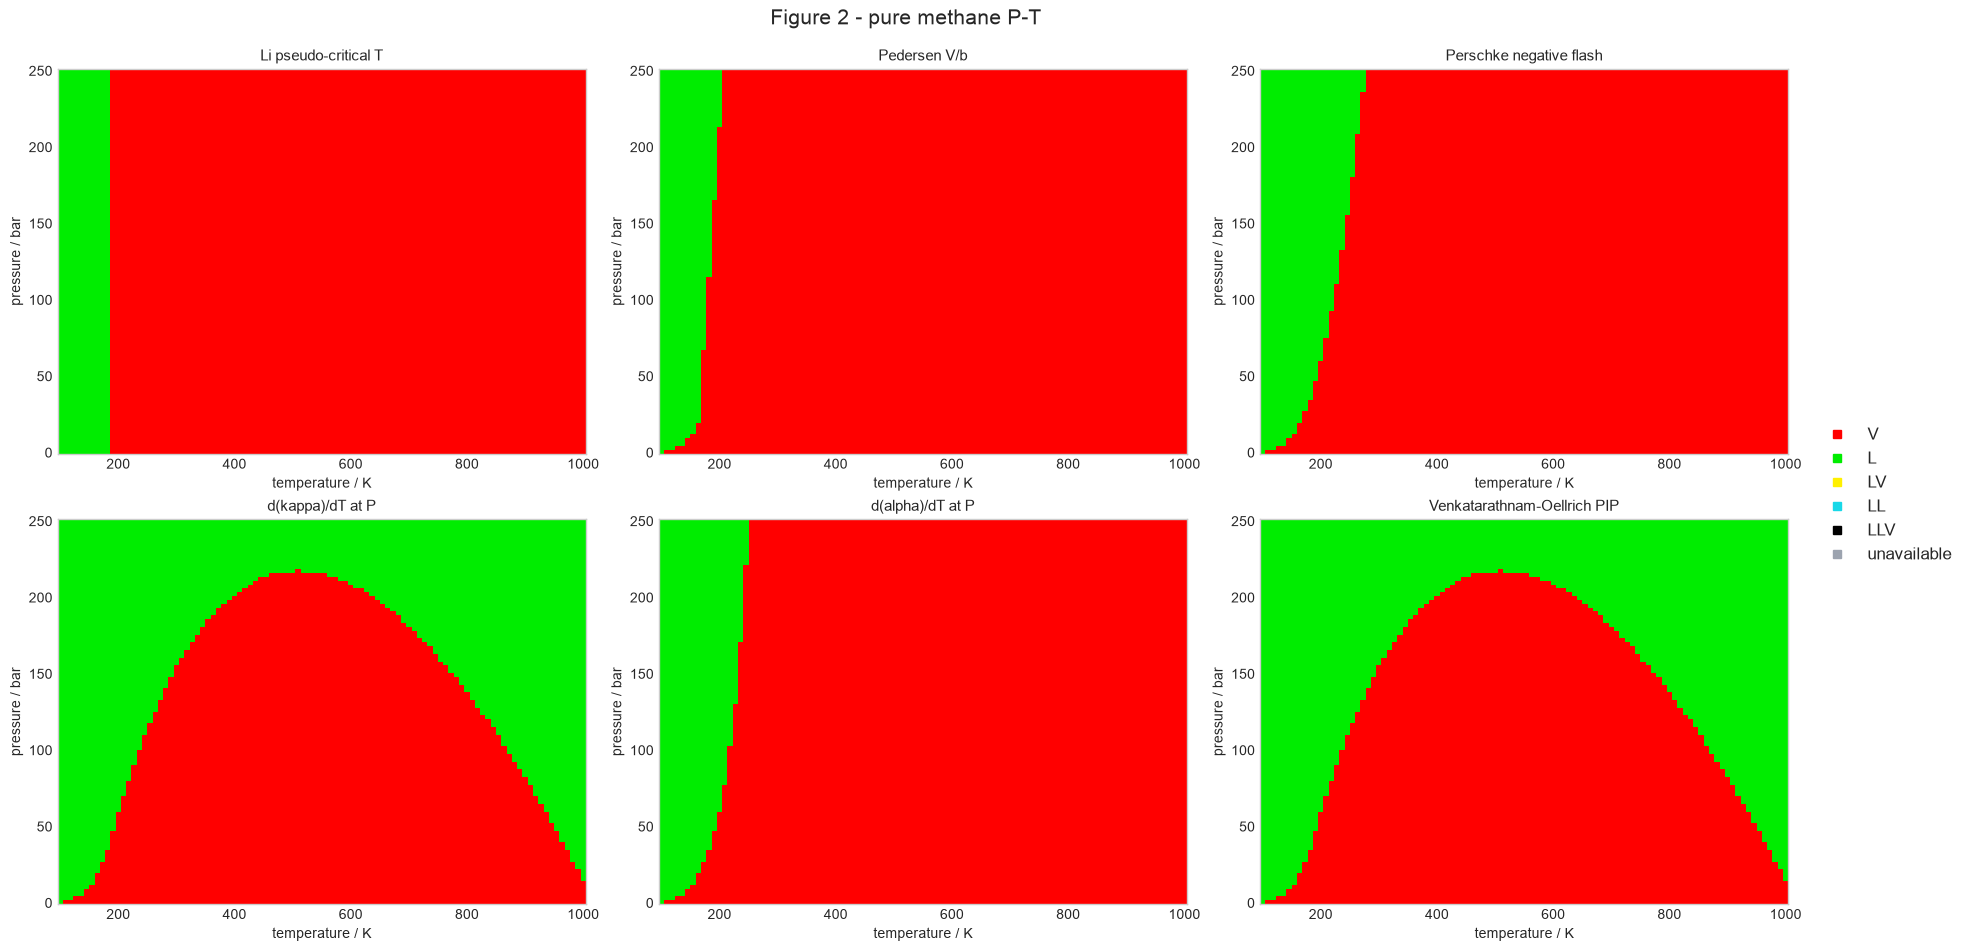

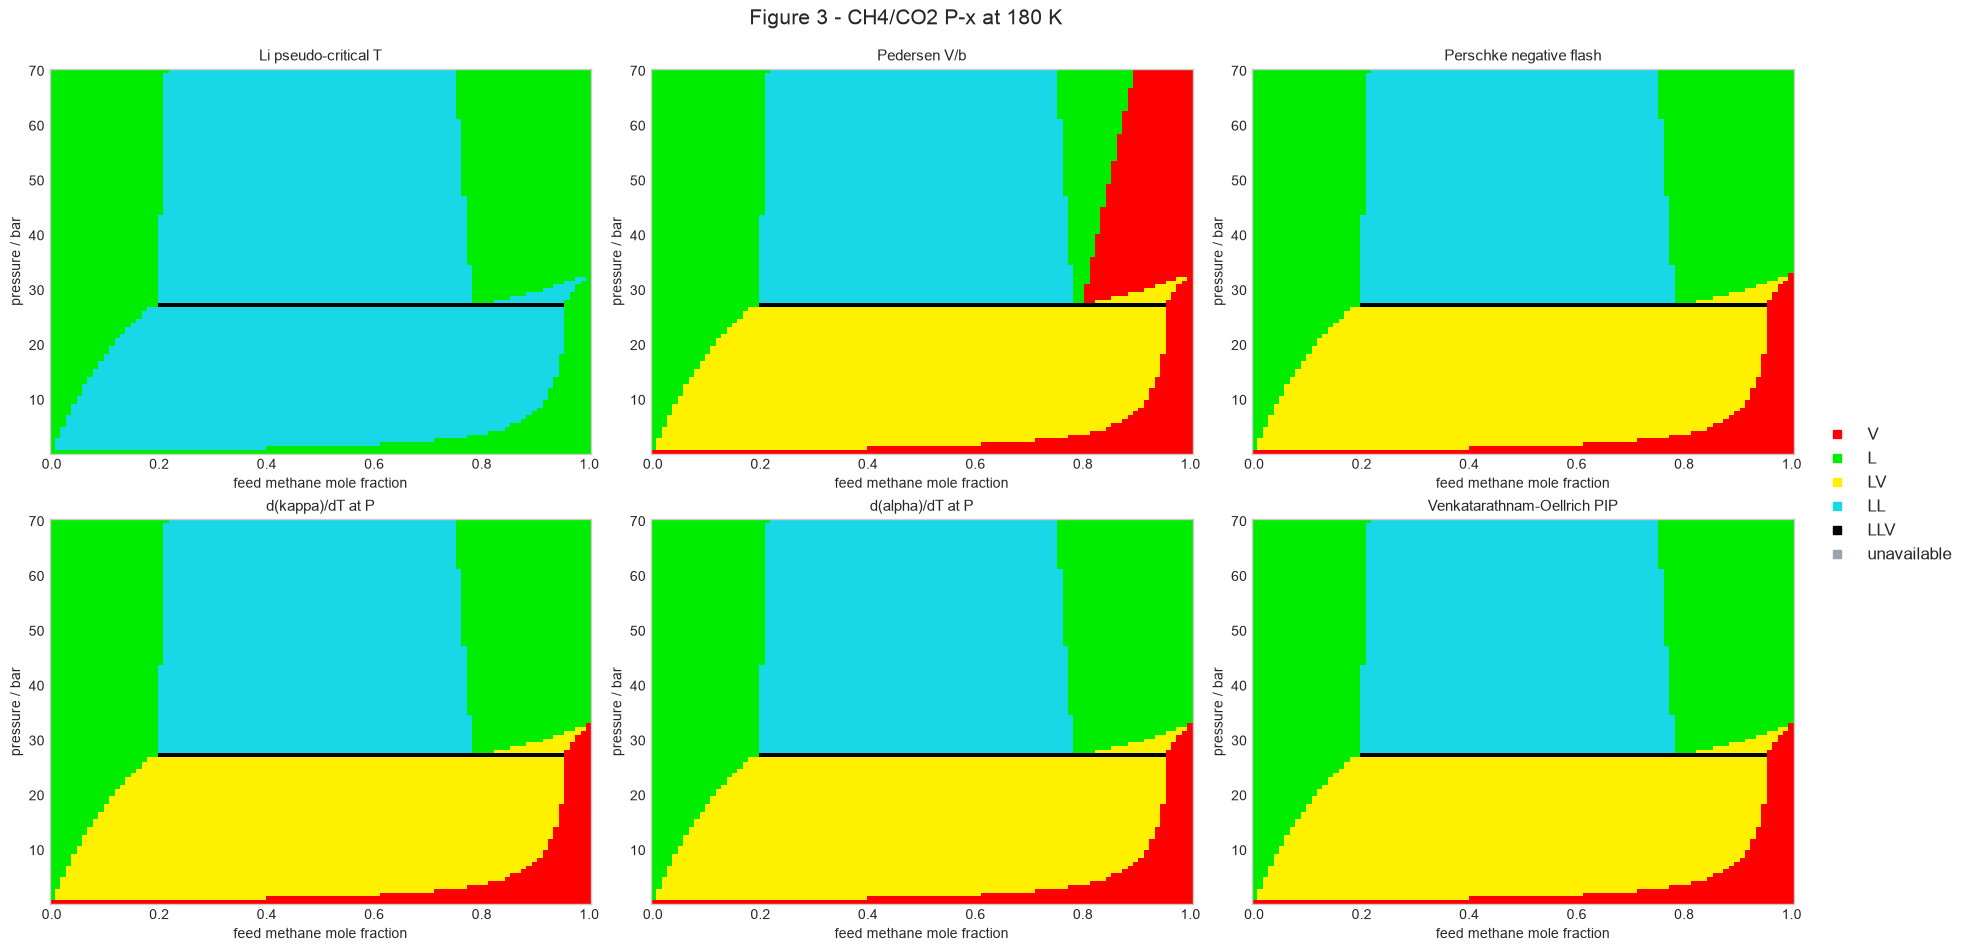

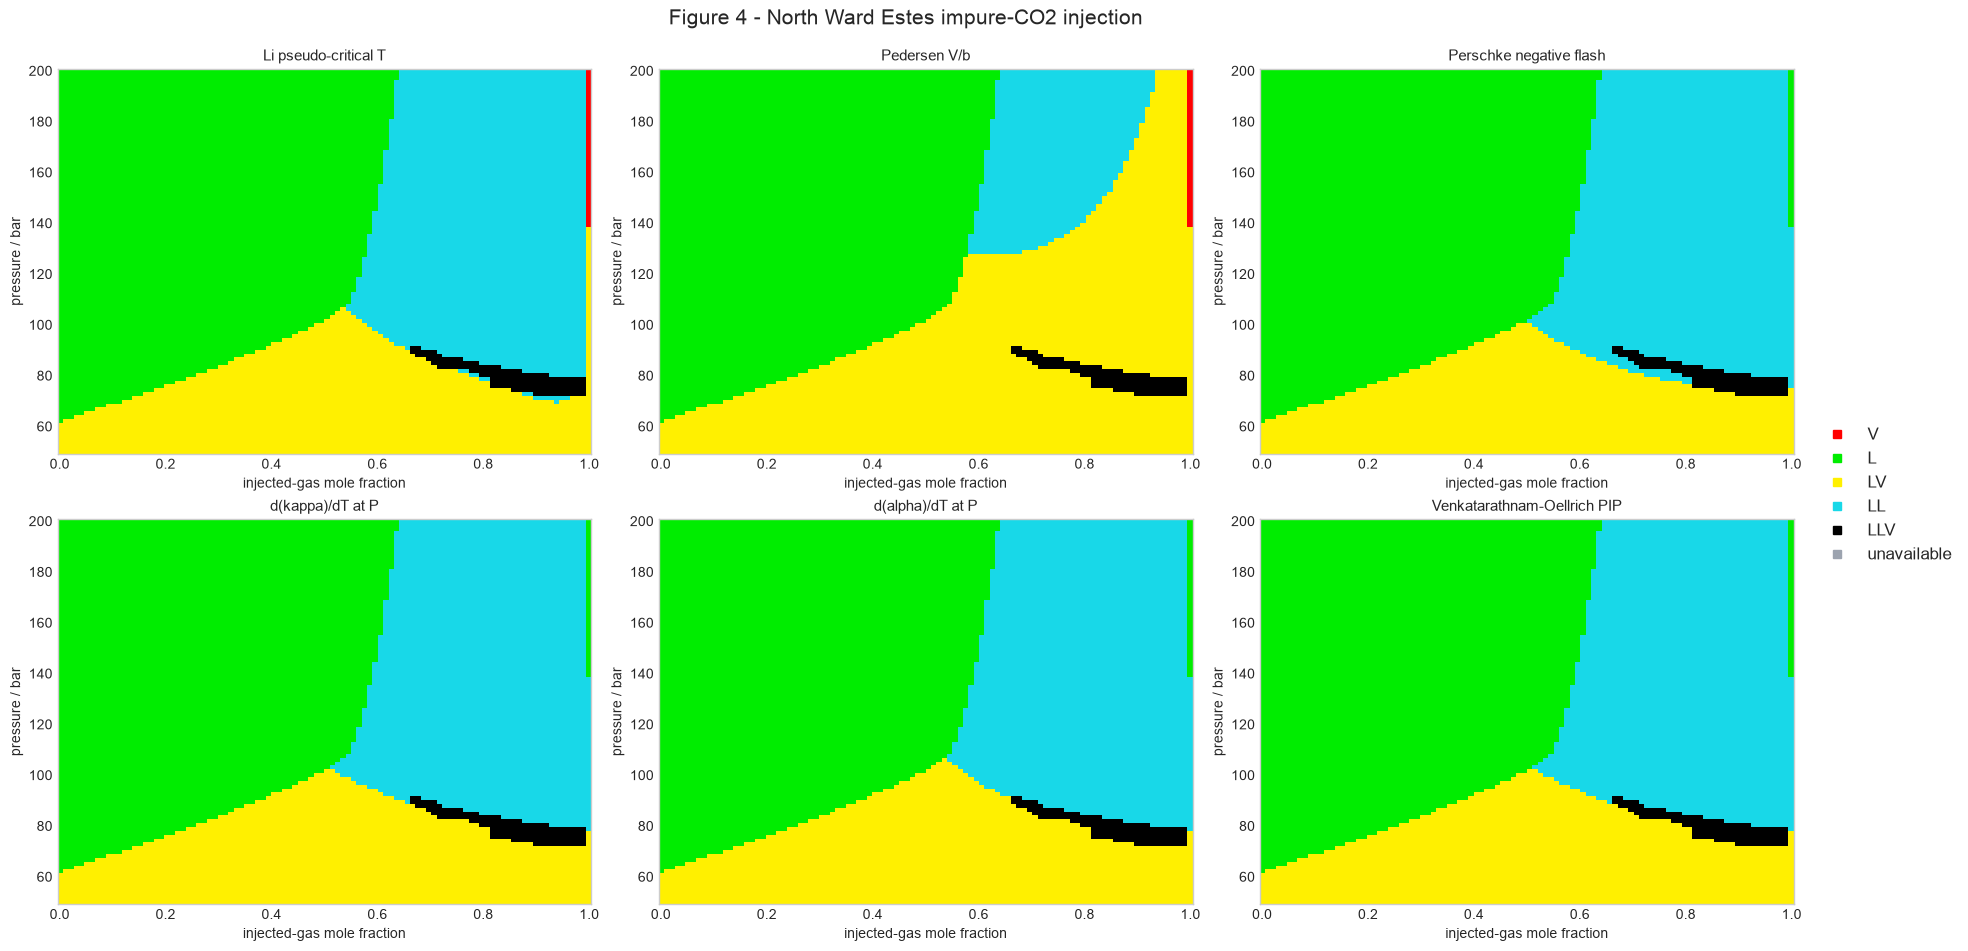

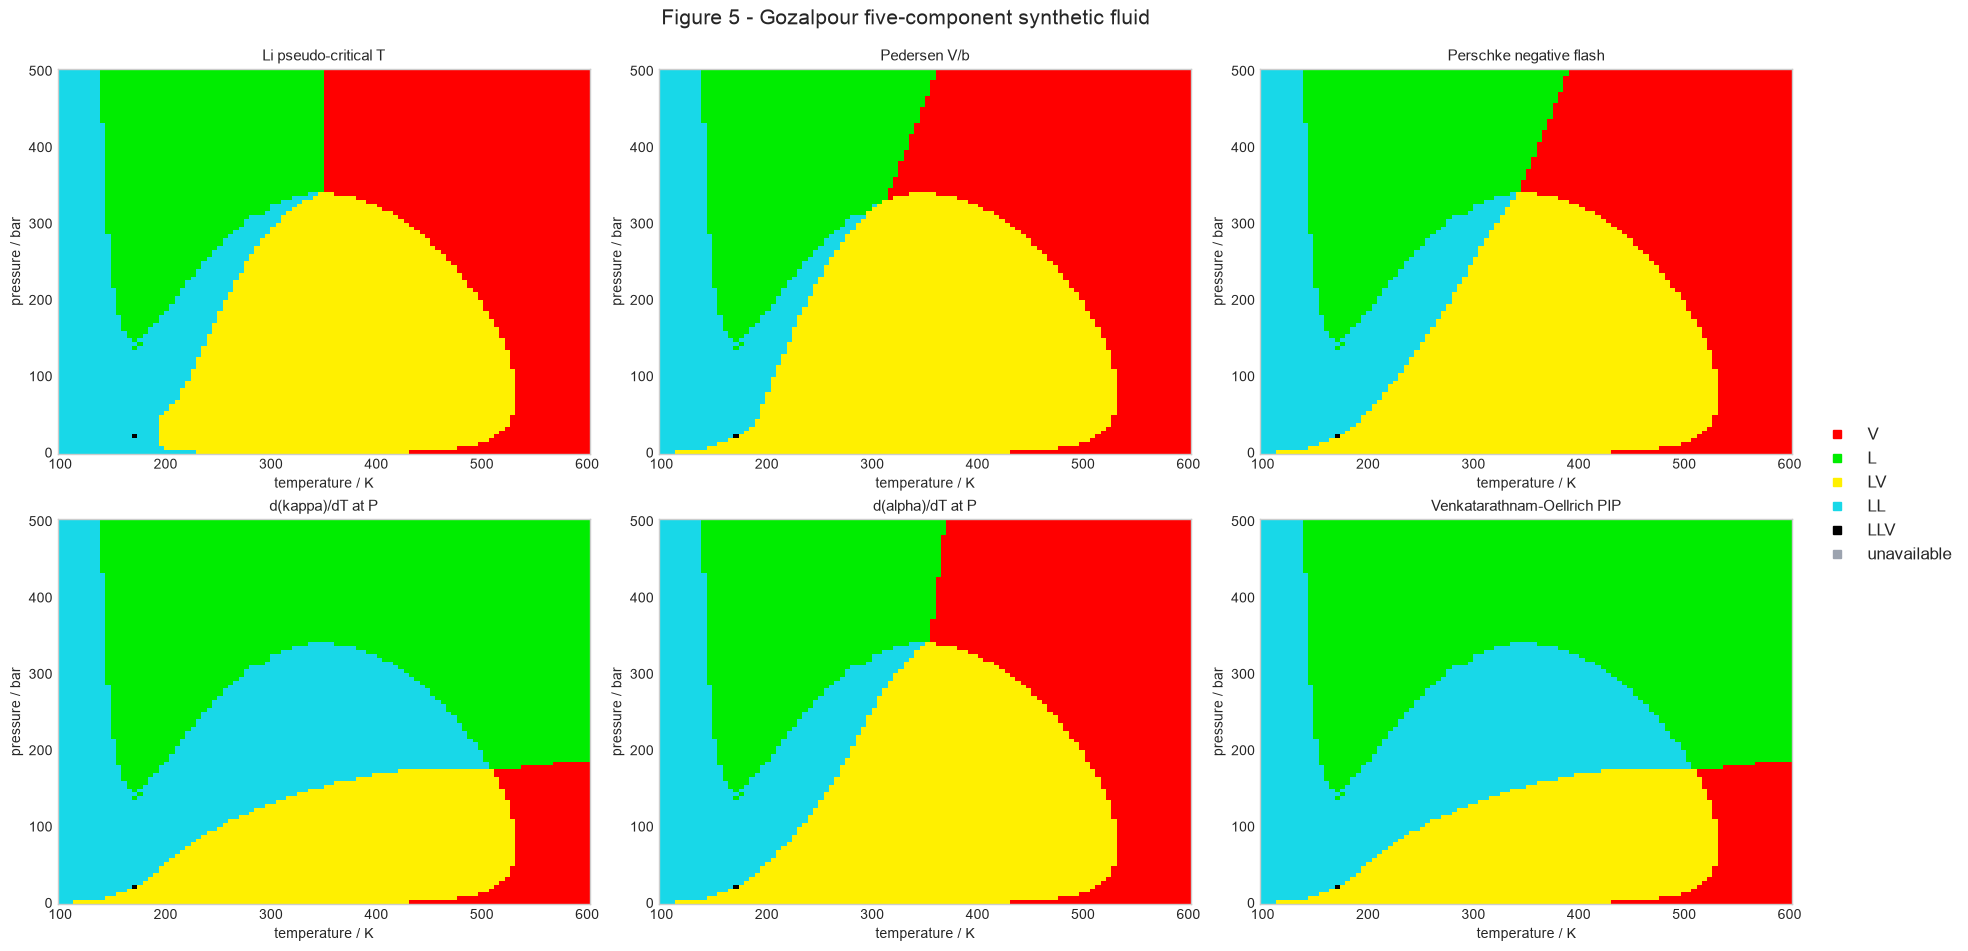

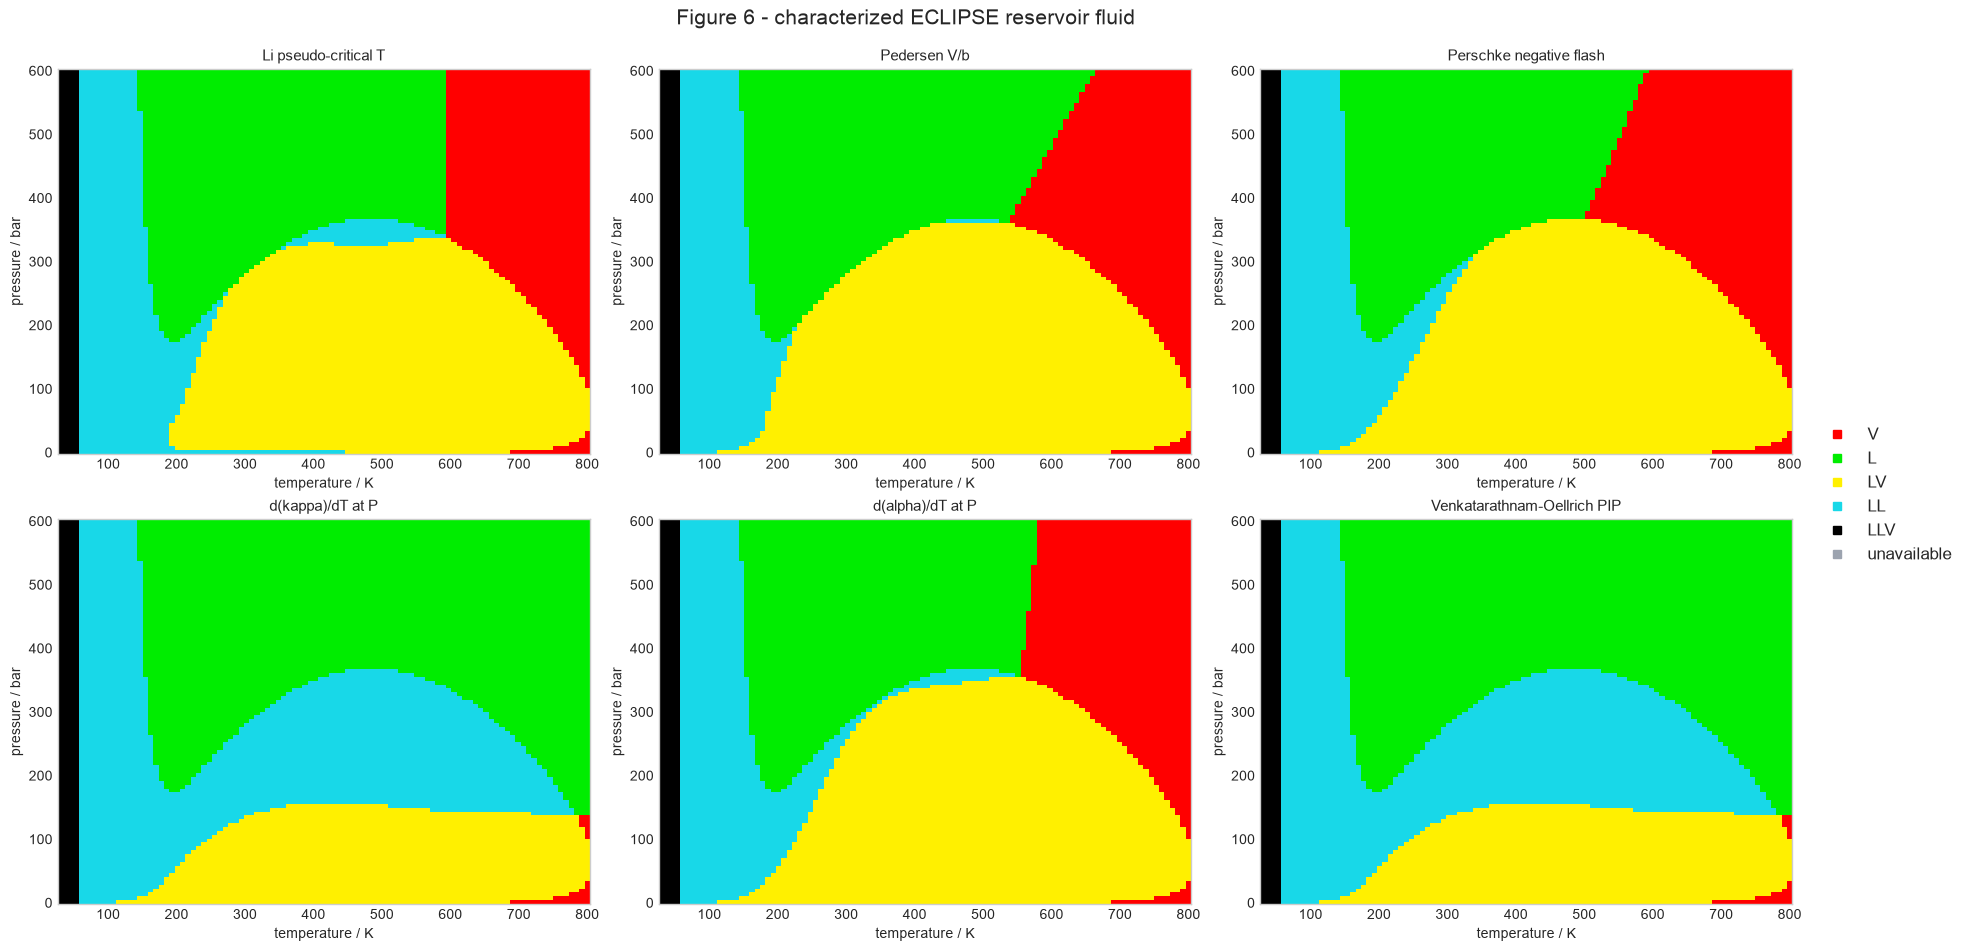

In [12]:
phase_cmap = ListedColormap(
    ["#ff0000", "#00ed00", "#fff000", "#18d8e8", "#000000", "#9ca3af"]
)
phase_norm = BoundaryNorm(np.arange(-0.5, 6.5), phase_cmap.N)


def plot_case(case: PaperCase, regions: dict[str, np.ndarray]) -> None:
    figure, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
    for axis, (method, phase_code) in zip(axes.flat, regions.items(), strict=False):
        axis.pcolormesh(
            case.horizontal.detach().numpy(),
            case.vertical_bar.detach().numpy(),
            phase_code,
            cmap=phase_cmap,
            norm=phase_norm,
            shading="nearest",
        )
        axis.set_title(method, fontsize=11)
        axis.set_xlabel(case.horizontal_label)
        axis.set_ylabel("pressure / bar")
    figure.legend(
        handles=[
            plt.Line2D(
                [],
                [],
                marker="s",
                linestyle="",
                color=phase_cmap(code),
                label=label,
            )
            for label, code in PHASE_CODES.items()
        ],
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=12,
    )
    figure.suptitle(case.name, fontsize=15, y=1.04)
    plt.show()


for current_case in CASES:
    plot_case(current_case, case_results[current_case.name])

## Quantitative map comparison

Pair agreement is the fraction of valid cells assigned the same complete
V/L/LV/LL/LLV code. Region fractions make missing or implausibly collapsed
multiphase structure visible; numerical availability alone is not treated as
reproduction evidence.

In [13]:
agreement_rows = []
for case in CASES:
    regions = case_results[case.name]
    all_values = np.stack(tuple(regions.values()))
    valid_all = (all_values != PHASE_CODES["unavailable"]).all(axis=0)
    disagreement = valid_all & (all_values.min(axis=0) != all_values.max(axis=0))
    for first_index, first in enumerate(METHODS):
        for second_index, second in enumerate(METHODS):
            if second_index <= first_index:
                continue
            valid = (regions[first] != PHASE_CODES["unavailable"]) & (
                regions[second] != PHASE_CODES["unavailable"]
            )
            pair_agreement = (
                np.mean(regions[first][valid] == regions[second][valid])
                if valid.any()
                else np.nan
            )
            agreement_rows.append(
                {
                    "case": case.name,
                    "method 1": first,
                    "method 2": second,
                    "pair agreement": pair_agreement,
                    "any-method disagreement": disagreement.mean(),
                }
            )

agreement_table = pd.DataFrame(agreement_rows)
display(
    agreement_table.groupby("case", as_index=False).agg(
        minimum_pair_agreement=("pair agreement", "min"),
        mean_pair_agreement=("pair agreement", "mean"),
        any_method_disagreement=("any-method disagreement", "first"),
    )
)

region_rows = []
for case in CASES:
    for method, values in case_results[case.name].items():
        valid = values != PHASE_CODES["unavailable"]
        for region, code in PHASE_CODES.items():
            if region == "unavailable":
                continue
            region_rows.append(
                {
                    "case": case.name,
                    "method": method,
                    "region": region,
                    "fraction of valid grid": np.mean(values[valid] == code),
                }
            )
display(
    pd.DataFrame(region_rows).pivot_table(
        index=["case", "method"],
        columns="region",
        values="fraction of valid grid",
    )
)

# For mechanically stable states, Eq. 17 is algebraically equivalent in sign
# to the isothermal-compressibility derivative criterion. Report the grid-level
# consequence explicitly instead of relying on visual similarity alone.
pip_equivalence_rows = []
for case in CASES:
    compressibility = case_results[case.name]["d(kappa)/dT at P"]
    pip = case_results[case.name]["Venkatarathnam-Oellrich PIP"]
    valid = (compressibility != PHASE_CODES["unavailable"]) & (
        pip != PHASE_CODES["unavailable"]
    )
    pip_equivalence_rows.append(
        {
            "case": case.name,
            "valid cells": int(valid.sum()),
            "different region codes": int((compressibility[valid] != pip[valid]).sum()),
            "region-code agreement": float(
                np.mean(compressibility[valid] == pip[valid])
            ),
        }
    )
pip_equivalence_table = pd.DataFrame(pip_equivalence_rows)
display(pip_equivalence_table)
assert (pip_equivalence_table["region-code agreement"] >= 0.98).all()

,case,minimum_pair_agreement,mean_pair_agreement,any_method_disagreement
0,Figure 2 - pure methane P-T,0.6405,0.807907,0.3643
1,Figure 3 - CH4/CO2 P-x at 180 K,0.5542,0.851400,0.4458
2,Figure 4 - North Ward Estes impure-CO2 injection,0.8001,0.930247,0.2009
3,Figure 5 - Gozalpour five-component synthetic ...,0.5805,0.778940,0.4263
4,Figure 6 - characterized ECLIPSE reservoir fluid,0.6380,0.797467,0.3867


region                                                                               L  \
case                                               method                                
Figure 2 - pure methane P-T                        Li pseudo-critical T         0.1000   
                                                   Pedersen V/b                 0.0953   
                                                   Perschke negative flash      0.1434   
                                                   Venkatarathnam-Oellrich PIP  0.4499   
                                                   d(alpha)/dT at P             0.1329   
                                                   d(kappa)/dT at P             0.4499   
Figure 3 - CH4/CO2 P-x at 180 K                    Li pseudo-critical T         0.3478   
                                                   Pedersen V/b                 0.2065   
                                                   Perschke negative flash      0.2944   
                                                   Venkatarathnam-Oellrich PIP  0.2944   
                                                   d(alpha)/dT at P             0.2944   
                                                   d(kappa)/dT at P             0.2944   
Figure 4 - North Ward Estes impure-CO2 injection   Li pseudo-critical T         0.4600   
                                                   Pedersen V/b                 0.4600   
                                                   Perschke negative flash      0.4641   
                                                   Venkatarathnam-Oellrich PIP  0.4641   
                                                   d(alpha)/dT at P             0.4641   
                                                   d(kappa)/dT at P             0.4641   
Figure 5 - Gozalpour five-component synthetic f... Li pseudo-critical T         0.2011   
                                                   Pedersen V/b                 0.1937   
                                                   Perschke negative flash      0.2122   
                                                   Venkatarathnam-Oellrich PIP  0.4545   
                                                   d(alpha)/dT at P             0.2088   
                                                   d(kappa)/dT at P             0.4545   
Figure 6 - characterized ECLIPSE reservoir fluid   Li pseudo-critical T         0.2817   
                                                   Pedersen V/b                 0.2839   
                                                   Perschke negative flash      0.2561   
                                                   Venkatarathnam-Oellrich PIP  0.4418   
                                                   d(alpha)/dT at P             0.2676   
                                                   d(kappa)/dT at P             0.4418   

region                                                                              LL  \
case                                               method                                
Figure 2 - pure methane P-T                        Li pseudo-critical T         0.0000   
                                                   Pedersen V/b                 0.0000   
                                                   Perschke negative flash      0.0000   
                                                   Venkatarathnam-Oellrich PIP  0.0000   
                                                   d(alpha)/dT at P             0.0000   
                                                   d(kappa)/dT at P             0.0000   
Figure 3 - CH4/CO2 P-x at 180 K                    Li pseudo-critical T         0.6447   
                                                   Pedersen V/b                 0.3402   
                                                   Perschke negative flash      0.3402   
                                                   Venkatarathnam-Oellrich PIP  0.3402   
                                       

,case,valid cells,different region codes,region-code agreement
0,Figure 2 - pure methane P-T,10000,0,1.0
1,Figure 3 - CH4/CO2 P-x at 180 K,10000,0,1.0
2,Figure 4 - North Ward Estes impure-CO2 injection,10000,0,1.0
3,Figure 5 - Gozalpour five-component synthetic ...,10000,0,1.0
4,Figure 6 - characterized ECLIPSE reservoir fluid,10000,0,1.0


### Paper-topology regression gates

These gates encode the visually distinctive features of Figures 2-6. They
complement, rather than replace, direct inspection of the saved plots.

In [14]:
if GRID_POINTS >= 9:
    methane_regions = case_results[methane_case.name]
    binary_regions = case_results[binary_case.name]
    nwe_regions = case_results[nwe_case.name]
    synthetic_regions = case_results[synthetic_case.name]
    reservoir_regions = case_results[reservoir_case.name]

    assert PHASE_CODES["V"] in methane_regions["d(kappa)/dT at P"]
    assert PHASE_CODES["L"] in methane_regions["d(kappa)/dT at P"]
    assert PHASE_CODES["LL"] in binary_regions["Li pseudo-critical T"]
    assert PHASE_CODES["LV"] not in binary_regions["Li pseudo-critical T"]
    assert PHASE_CODES["LLV"] in binary_regions["Perschke negative flash"]
    assert PHASE_CODES["LV"] in synthetic_regions["Perschke negative flash"]
    assert PHASE_CODES["LL"] in synthetic_regions["d(kappa)/dT at P"]
    assert PHASE_CODES["LLV"] in reservoir_regions["Li pseudo-critical T"]
    assert PHASE_CODES["LL"] in reservoir_regions["Perschke negative flash"]
    if GRID_POINTS >= 17:
        # Figure 4's three-phase strip is narrower than the 9 x 9 smoke spacing.
        assert PHASE_CODES["LLV"] in nwe_regions["d(alpha)/dT at P"]
        nwe_equilibrium = case_equilibria[nwe_case.name]
        nwe_phase_counts = nwe_equilibrium.phase_counts.reshape(
            nwe_equilibrium.grid_shape
        )
        vertical_three_phase_holes = (
            (nwe_phase_counts[1:-1] == 2)
            & (nwe_phase_counts[:-2] == 3)
            & (nwe_phase_counts[2:] == 3)
        )
        assert not bool(vertical_three_phase_holes.any())

## Public-API audit on flashed phases

This table calls the scalar `identify_phase` API, complementing the batched
public `identify_grid_phases` API used to build the maps. As in the maps, its
composition is an equilibrium-phase composition returned by the grid flash,
not the feed.
The stored criterion is in its native units: \(T/T_c\), \(V/b\), \(G(0.5)\),
1/(Pa K), 1/K², or dimensionless \(\Pi\).

In [15]:
api_rows = []
for case in CASES:
    equilibrium = case_equilibria[case.name]
    flat_index = equilibrium.temperatures.numel() // 2
    if not bool(equilibrium.converged[flat_index]):
        raise RuntimeError(f"public-API audit flash failed for {case.name}")
    for phase_index in range(int(equilibrium.phase_counts[flat_index])):
        state = ChemicalState(
            equilibrium.temperatures[flat_index],
            equilibrium.pressures[flat_index],
            equilibrium.phase_compositions[flat_index, phase_index],
        )
        for label, method in METHODS.items():
            result = identify_phase(case.model, state, method=method)
            api_rows.append(
                {
                    "case": case.name,
                    "equilibrium phase": phase_index,
                    "method": label,
                    "identity": result.kind,
                    "criterion": (
                        np.nan
                        if result.criterion_value is None
                        else float(result.criterion_value.detach())
                    ),
                    "threshold": (
                        np.nan
                        if result.threshold is None
                        else float(result.threshold.detach())
                    ),
                    "ambiguous": result.ambiguous,
                }
            )

api_table = pd.DataFrame(api_rows)
display(api_table)
assert api_table["criterion"].notna().all()

,case,equilibrium phase,method,identity,criterion,threshold,ambiguous
0,Figure 2 - pure methane P-T,0,Li pseudo-critical T,liquid,5.247581e-01,1.00,False
1,Figure 2 - pure methane P-T,0,Pedersen V/b,liquid,1.186913e+00,1.75,False
2,Figure 2 - pure methane P-T,0,Perschke negative flash,liquid,-1.989430e+00,0.00,False
3,Figure 2 - pure methane P-T,0,d(kappa)/dT at P,liquid,3.395019e-11,0.00,False
4,Figure 2 - pure methane P-T,0,d(alpha)/dT at P,liquid,2.723437e-05,0.00,False
5,Figure 2 - pure methane P-T,0,Venkatarathnam-Oellrich PIP,liquid,1.075199e+01,1.00,False
6,Figure 3 - CH4/CO2 P-x at 180 K,0,Li pseudo-critical T,liquid,5.919495e-01,1.00,False
7,Figure 3 - CH4/CO2 P-x at 180 K,0,Pedersen V/b,liquid,1.227451e+00,1.75,False
8,Figure 3 - CH4/CO2 P-x at 180 K,0,Perschke negative flash,liquid,-1.912552e+00,0.00,False
9,Figure 3 - CH4/CO2 P-x at 180 K,0,d(kappa)/dT at P,liquid,2.307431e-11,0.00,False


## Higher-order autodiff audit

A trainable CH₄/CO₂ interaction is used to verify that Bennett's
\((\partial\alpha/\partial T)_P\) criterion and the
Venkatarathnam-Oellrich parameter remain connected to both the temperature
and model-parameter graph. Their native units differ, so the audit reports
raw values and checks finite, nonzero sensitivities rather than comparing
their magnitudes.

In [16]:
gradient_rows = []
for criterion_label, criterion_method in (
    ("d(alpha)/dT at P", "bennett-thermal-expansion-derivative"),
    (
        "Venkatarathnam-Oellrich PIP",
        "venkatarathnam-oellrich-phase-identification-parameter",
    ),
):
    gradient_model = peng_robinson_1978(
        binary_components,
        kij=binary_kij,
        trainable=True,
    )
    gradient_temperature = torch.tensor(180.0, requires_grad=True)
    gradient_state = ChemicalState(
        gradient_temperature,
        torch.tensor(3.0e6),
        torch.tensor([0.5, 0.5]),
    )
    gradient_identification = identify_phase(
        gradient_model,
        gradient_state,
        method=criterion_method,
    )
    if gradient_identification.criterion_value is None:
        raise RuntimeError(f"{criterion_label} unexpectedly unavailable")
    temperature_gradient, interaction_gradient = torch.autograd.grad(
        gradient_identification.criterion_value,
        (gradient_temperature, gradient_model.mixing.raw_kij),
    )
    gradient_rows.append(
        {
            "criterion": criterion_label,
            "criterion value (native units)": float(
                gradient_identification.criterion_value.detach()
            ),
            "d criterion / dT (native units/K)": float(temperature_gradient),
            "off-diagonal d criterion / dkij (native units)": float(
                interaction_gradient[0, 1]
            ),
            "all gradients finite": bool(
                torch.isfinite(temperature_gradient)
                & torch.isfinite(interaction_gradient).all()
            ),
        }
    )

gradient_audit = pd.DataFrame(gradient_rows)
display(gradient_audit)
assert gradient_audit["all gradients finite"].all()
assert (
    gradient_audit["off-diagonal d criterion / dkij (native units)"].abs() > 0.0
).all()

,criterion,criterion value (native units),d criterion / dT (native units/K),off-diagonal d criterion / dkij (native units),all gradients finite
0,d(alpha)/dT at P,0.000084,0.000003,0.000110,True
1,Venkatarathnam-Oellrich PIP,7.906052,-0.041261,-1.385216,True


## Conclusions and limitations

- Every plotted cell is flashed first. Only converged equilibrium phase
  compositions that pass fugacity and material-balance gates are passed to
  the six identification criteria.
- The six maps recover the paper's defining topology and method-specific
  differences: the methane compressibility dome, binary LV/LL divider,
  North Ward Estes three-phase band, synthetic-fluid envelope, and the main
  reservoir-fluid envelope with its low-temperature LLV/LL strip.
- The Venkatarathnam-Oellrich map agrees with the
  \((\partial\kappa/\partial T)_P\) map, as expected from the algebraic
  relation between the two criteria on mechanically stable states.
- All three derivative methods use second-order PyTorch autodiff. Both
  explicitly audited criteria retain gradients to temperature and a
  trainable EoS interaction.
- The Venkatarathnam-Oellrich grid path batches independent phases in
  configurable chunks and uses nested forward-mode JVPs, avoiding a dense
  cross-state Jacobian.
- Total identification time and a per-method, per-equilibrium-phase timing
  are reported separately from the flash time.
- Li and Firoozabadi publish all North Ward Estes PR equilibrium inputs.
  Their table omits critical volumes, which are derived consistently from PR
  only for the Li phase-identification diagnostic and do not affect the
  equilibrium flash. The published Table 9 state is independently recovered
  as three-phase.
- The ECLIPSE table omits the complete EOS/BIC input; Figure 6 is
  therefore labeled as the transparent
  `bennett-figure6-reconstruction-v1`, not as the unpublished ECLIPSE
  parameterization. Its thin higher-temperature/low-pressure LLV branch is
  not reproduced by this reconstruction on the 100 by 100 grid. No
  additional temperature-dependent or lump-specific interactions are
  inferred from the raster.
- These results are **verification of the implemented diagnostics**, not
  validation against experimental phase labels. The saved 100 by 100 maps
  resolve the topology; they are not pixel-wise validation of the paper's 500 by 500
  raster.

For a denser study, set `TORCH_FLASH_PHASE_ID_GRID_POINTS` before execution.
The paper reports rerunning illustrative plots on 500 by 500 grids; that
profile is intentionally not the default because the strict flash residual
gates make it substantially more expensive.